# Machine Learning (ML)-based Ground Motion Model (GMM) - Tutorial

# 1. Data processing

In ground motion modeling, maintaining a balanced magnitude distribution across training and testing sets is crucial. 
We will load our dataset and check its basic parameters.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv('data/gmm_dataset_sample.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (8956, 7)


,EQID,Mw,SoF,Dip,RJB,VS30,PGV_geo
0,146,3.8,S,61.0,88.259786,481.0,0.041942
1,209,4.2,S,68.0,116.082342,373.0,0.037115
2,414,4.1,S,66.0,102.826557,371.0,0.011931
3,735,4.2,S,87.0,73.779539,369.0,0.063621
4,493,4.0,N,65.0,161.150218,324.0,0.030800


## 1.1 Splitting the dataset: training and test sets

In earthquake datasets, small magnitude events (e.g., $M_w < 5.5$) dominate the catalogue, while high-magnitude earthquakes (e.g., $M_w \ge 6.5$) are rare because of their nature. A random train-test split risks placing all or most of the rare, high-magnitude events into just one set. 

By binning $M_w$, we guarantee that both the training and testing sets retain the exact same magnitude proportions (e.g., 80% train / 20% test per bin), preventing data imbalance and ensuring the model learns effectively across all earthquake sizes.

We define four magnitude bins and split each bin as 80% for training and 20% for testing.
- M 3.5-4.4
- M 4.5-5.4
- M 5.5-6.4
- M > 6.4

In [3]:
bins = [3.5, 4.5, 5.5, 6.5, np.inf]
labels = ['3.5-4.4', '4.5-5.4', '5.5-6.4', '>=6.5']
df['mw_bin'] = pd.cut(df['Mw'], bins=bins, labels=labels, right=False)

# Number of events within each bins
print("Number of recordings per magnitude bin: ")
print(df['mw_bin'].value_counts().sort_index())

Number of recordings per magnitude bin: 
mw_bin
3.5-4.4    4512
4.5-5.4    3823
5.5-6.4     444
>=6.5       177
Name: count, dtype: int64


In [4]:
out_dir = os.path.join("output")
os.makedirs(out_dir, exist_ok=True)

train_df, test_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['mw_bin']
)

train_df = train_df.drop(columns=['mw_bin'])
test_df = test_df.drop(columns=['mw_bin'])

print(f"\nTraining Set : {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Testing Set : {len(test_df)} ({len(test_df)/len(df):.1%})")

train_df.to_csv('output/train_set.csv', index=False)
test_df.to_csv('output/test_set.csv', index=False)

print("Train and Test datasets are saved to 'output/' folder!")


Training Set : 7164 (80.0%)
Testing Set : 1792 (20.0%)
Train and Test datasets are saved to 'output/' folder!


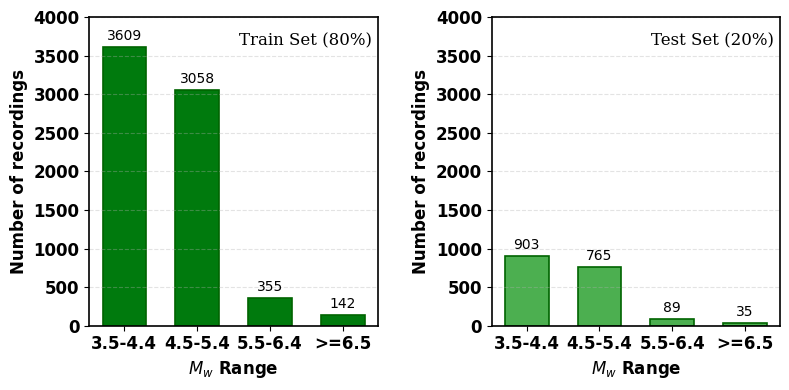

In [5]:
# Vis of training and test ssets
bins = [3.5, 4.5, 5.5, 6.5, np.inf]
labels = ['3.5-4.4', '4.5-5.4', '5.5-6.4', '>=6.5']

train_df['mw_bin'] = pd.cut(train_df['Mw'], bins=bins, labels=labels, right=False)
test_df['mw_bin'] = pd.cut(test_df['Mw'], bins=bins, labels=labels, right=False)

split_report_df = pd.DataFrame({
    'Mw_bin': labels,
    'Train': train_df['mw_bin'].value_counts().reindex(labels).values,
    'Test': test_df['mw_bin'].value_counts().reindex(labels).values
})

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

x = np.arange(len(labels))

datasets = [
    ("Train", "Train Set (80%)", "#007a0d"),
    ("Test", "Test Set (20%)", "#4caf50")
]

max_val = max(split_report_df['Train'].max(), split_report_df['Test'].max())
y_limit = int(np.ceil(max_val / 1000.0)) * 1000 if max_val > 1000 else int(np.ceil(max_val / 100.0)) * 100

for ax, (col, title, color) in zip(axes, datasets):

    bars = ax.bar(x, split_report_df[col], width=0.60, color=color, edgecolor="darkgreen", linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight="bold")

    ax.set_ylim(0, y_limit)
    ax.tick_params(axis="y", labelsize=12, colors="black")

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.set_xlabel(r"$M_{w}$ Range", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of recordings", fontsize=12, fontweight="bold")
    ax.text(0.98, 0.95, title, transform=ax.transAxes, ha="right", va="top", fontsize=12, family="serif", color="black")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.2)

plt.tight_layout(w_pad=2.5)
plt.show()

## 1.2 Encoding

Style of Faulting (SoF) contains categorical string values: **S** (Strike-Slip), **N** (Normal), and **R** (Reverse). 
Machine learning regression algorithms require numeric input. So, we should transform `SoF` into binary columns using one of encoding methods.<br>

Some commonly utilized methods are
- **One-Hot Encoding**: Creates a separate boolean column ($0$ or $1$) for each unique category to indicate its presence.
- **Frequency Encoding**: Replaces each category with its relative frequency or proportion of occurrence in the dataset.  If $60\%$ of earthquakes in dataset are SS -> 0.6 for SS.
- **Binary Encoding**: Converts categories into sequential integers and expresses those integers as binary digits (e.g., 00, 01, 10).

In [6]:
def encode_sof(df_train, df_test):
    ''' Perform One-Hot Encoding on training and testing sets '''
    train_encoded = pd.get_dummies(df_train, columns=['SoF'], prefix='SoF', dtype=int)
    test_encoded = pd.get_dummies(df_test, columns=['SoF'], prefix='SoF', dtype=int)
    
    # Ensure both datasets have the same dummy columns
    train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)
    
    return train_encoded, test_encoded

# Apply encoding to split sets
train_df_encoded, test_df_encoded = encode_sof(train_df, test_df)

print("--- Encoded Training Set Preview ---")
print(train_df_encoded[['Mw', 'SoF_N', 'SoF_R', 'SoF_S']].head())

--- Encoded Training Set Preview ---
       Mw  SoF_N  SoF_R  SoF_S
2359  4.3      0      0      1
4083  4.2      0      1      0
1811  4.1      1      0      0
7826  4.5      1      0      0
8932  7.1      0      0      1


## 1.3 Min-Max normalization

The parameters utilized in constructing ML-based models may exhibit varying ranges and units, such as Vs30 (varying from 130 m/s to 1700 m/s) and dip angle (varying from 0 to 90 degrees). <br> If such estimator parameters are incorporated into the model development process without adjustment, the Vs30 value may disproportionately influence prediction compared to δ. Therefore, we will normalize selected continuous input features (`Mw`, `VS30`, `Dip`, `RJB`) into a specified range of **[0.2, 0.8]**.

In [7]:
# Features to be normalized
features_to_scale = ['Mw', 'VS30', 'Dip', 'RJB']

# MinMaxScaler with feature range [0.2, 0.8]
scaler = MinMaxScaler(feature_range=(0.2, 0.8))

train_scaled = train_df_encoded.copy()
test_scaled = test_df_encoded.copy()

# Fit scaler
train_scaled[features_to_scale] = scaler.fit_transform(train_df_encoded[features_to_scale])
test_scaled[features_to_scale] = scaler.transform(test_df_encoded[features_to_scale])

# Display
print("Training Set Normalized Feature Ranges: ")
for col in features_to_scale:
    print(f"{col:6s} -> Min: {train_scaled[col].min():.2f}, Max: {train_scaled[col].max():.2f}")

print("\nNormalized Training Set Sample: ")
display(train_scaled[features_to_scale + ['SoF_N', 'SoF_R', 'SoF_S']].head())

Training Set Normalized Feature Ranges: 
Mw     -> Min: 0.20, Max: 0.80
VS30   -> Min: 0.20, Max: 0.80
Dip    -> Min: 0.20, Max: 0.80
RJB    -> Min: 0.20, Max: 0.80

Normalized Training Set Sample: 


,Mw,VS30,Dip,RJB,SoF_N,SoF_R,SoF_S
2359,0.311628,0.268977,0.754666,0.648707,0,0,1
4083,0.297674,0.286655,0.800000,0.668275,0,1,0
1811,0.283721,0.268284,0.535550,0.488166,1,0,0
7826,0.339535,0.250607,0.437325,0.487631,1,0,0
8932,0.702326,0.268787,0.611107,0.692126,0,0,1


## 1.4 Feature selection

Feature selection methods in the machine learning domain are crucial due to the presence of many irrelevant, redundant, and noisy features in the data. These factors can negatively impact predictive accuracy and increase computational burden (Pashaei and Pashaei 2022). However, real earthquake recordings are not homogeneous, as moderate-to-large magnitude earthquakes occur less frequently than small earthquakes, leading to differences in feature representation.

Therefore, it is also important to understand if feature selection is a feasible application for the prediction of GMIMs. You may find details in Kuran et al. (2023). 

Here, we evaluate the Pearson correlation coefficients between the scaled/encoded input features (`Mw`, `VS30`, `Dip`, `RJB`, `SoF_N`, `SoF_R`, `SoF_S`) and our target `ln_PGV_geo`.

Pearson Correlation Coefficients with Target (ln_PGV_geo): 


,ln_PGV_geo
ln_PGV_geo,1.000
Mw,0.676
SoF_N,0.028
SoF_S,-0.007
SoF_R,-0.052
Dip,-0.103
VS30,-0.223
RJB,-0.345


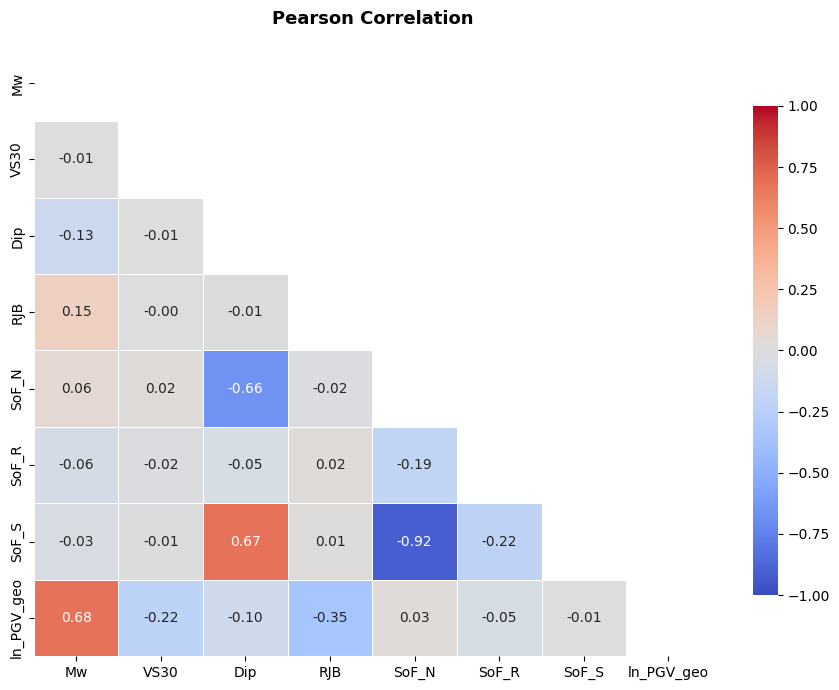

In [8]:
# Target Variable -> ln(PGV_geo)
train_scaled['ln_PGV_geo'] = np.log(train_scaled['PGV_geo'])
test_scaled['ln_PGV_geo'] = np.log(test_scaled['PGV_geo'])

# Features and Target
input_features = ['Mw', 'VS30', 'Dip', 'RJB', 'SoF_N', 'SoF_R', 'SoF_S']
target = 'ln_PGV_geo'

# Create a subset for correlation analysis
corr_df = train_scaled[input_features + [target]]

# Compute Pearson Correlation Matrix
corr_matrix = corr_df.corr(method='pearson')

print("Pearson Correlation Coefficients with Target (ln_PGV_geo): ")
target_corr = corr_matrix[[target]].sort_values(by=target, ascending=False)
display(target_corr.round(3))

# Plotting
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide duplicate upper triangle

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1,
    mask=mask,
    cbar_kws={"shrink": .8},
    linewidths=0.5
)

plt.title('Pearson Correlation', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 1.5 Outlier Detection and Elimination

To prevent extreme recording errors or unphysical anomalies from distorting model training, outlier detection and elimination is a technique of detecting data points with extreme values relative to the rest of the distribution. Outliers have a remarkable effect on computations like mean and standard deviation, which can have a strong influence on ML-based models.

**Interquartile Range (IQR)** is one of outlier detection methods for variables (like `ln_PGV_geo`). The IQR is employed by dividing a
data set into quartiles which are represented as Q25 (the 25th percentile of the feature) and Q75 (the 75th percentile of the data). IQR given below stands for the interval between the first and third quartiles. Data points both below **Q25 - 1.5IQR** and above **Q75 + 1.5IQR** are detected as outliers.

In [9]:
def detect_iqr_bounds(df, target_col, factor=1.5):
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (factor * IQR)
    upper_bound = Q3 + (factor * IQR)
    return lower_bound, upper_bound

# Calculate bounds based strictly on Training set
lower_b, upper_b = detect_iqr_bounds(train_scaled, 'ln_PGV_geo', factor=1.5)

print(f"Outlier detection bounds for ln_PGV_geo: ")
print(f"Lower Bound (Q1 - 1.5*IQR): {lower_b:.4f}")
print(f"Upper Bound (Q3 + 1.5*IQR): {upper_b:.4f}")

# Filter outliers from training and test sets
train_clean = train_scaled[(train_scaled['ln_PGV_geo'] >= lower_b) & (train_scaled['ln_PGV_geo'] <= upper_b)].copy()
test_clean = test_scaled[(test_scaled['ln_PGV_geo'] >= lower_b) & (test_scaled['ln_PGV_geo'] <= upper_b)].copy()

# Summary
train_removed = len(train_scaled) - len(train_clean)
test_removed = len(test_scaled) - len(test_clean)

print("\nOutlier removal summary: ")
print(f"Training Set: Removed {train_removed} rows ({train_removed / len(train_scaled):.2%}) | Remaining: {len(train_clean)}")
print(f"Testing Set : Removed {test_removed} rows ({test_removed / len(test_scaled):.2%}) | Remaining: {len(test_clean)}")

Outlier detection bounds for ln_PGV_geo: 
Lower Bound (Q1 - 1.5*IQR): -6.5517
Upper Bound (Q3 + 1.5*IQR): 0.6021

Outlier removal summary: 
Training Set: Removed 185 rows (2.58%) | Remaining: 6979
Testing Set : Removed 43 rows (2.40%) | Remaining: 1749


/var/folders/2z/fybvd81s1zs7dw0tm4l9g4600000gn/T/ipykernel_25978/1959086897.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Dataset', y='ln_PGV_geo', palette=['#e74c3c', '#2ecc71'], ax=axes[0], width=0.4)


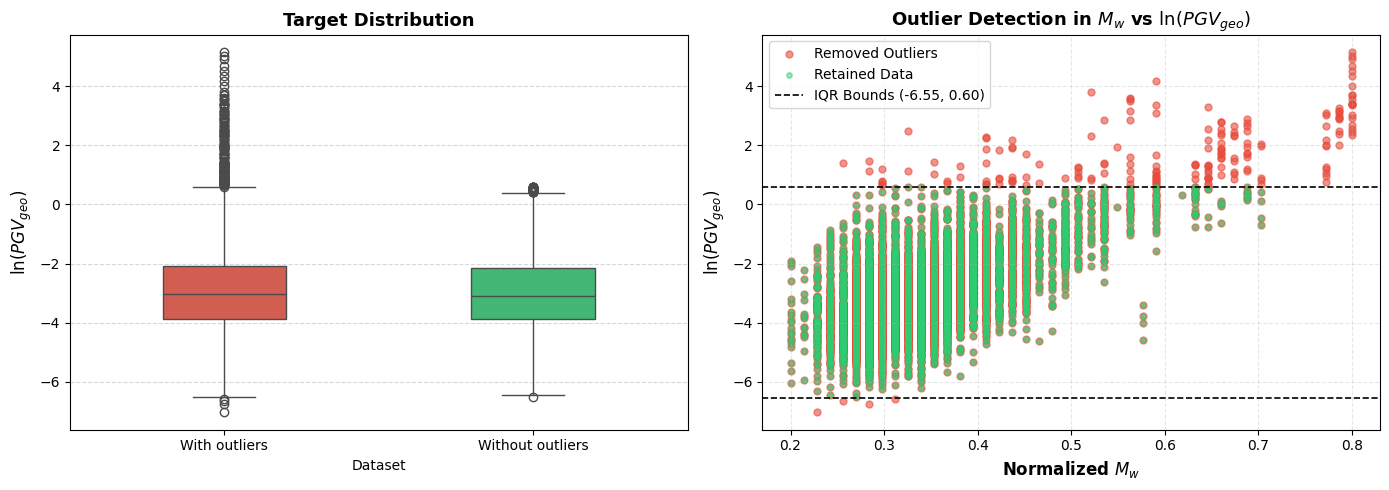

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1
plot_data = pd.DataFrame({
    'With outliers': train_scaled['ln_PGV_geo'],
    'Without outliers': train_clean['ln_PGV_geo']
}).melt(var_name='Dataset', value_name='ln_PGV_geo')

sns.boxplot(data=plot_data, x='Dataset', y='ln_PGV_geo', palette=['#e74c3c', '#2ecc71'], ax=axes[0], width=0.4)
axes[0].set_title('Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel(r'$\ln(PGV_{geo})$', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2
axes[1].scatter(train_scaled['Mw'], train_scaled['ln_PGV_geo'], color='#e74c3c', alpha=0.6, label='Removed Outliers', s=25)
axes[1].scatter(train_clean['Mw'], train_clean['ln_PGV_geo'], color='#2ecc71', alpha=0.5, label='Retained Data', s=15)
axes[1].axhline(lower_b, color='black', linestyle='--', linewidth=1.2, label=f'IQR Bounds ({lower_b:.2f}, {upper_b:.2f})')
axes[1].axhline(upper_b, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title(r'Outlier Detection in $M_w$ vs $\ln(PGV_{geo})$', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Normalized $M_w$', fontsize=12, fontweight='bold')
axes[1].set_ylabel(r'$\ln(PGV_{geo})$', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Training and Testing 

## 2.1 Gradient Boosting ML algorithm (with Default Hyperparameters)

We build a baseline Ground Motion Model using the **Gradient Boosting Regressor** algorithm.  In this step, we train the model on the full normalized dataset (without outlier removal) using Scikit-Learn's **default hyperparameters** to predict PGV.

Input Features (X): `Mw`, `VS30`, `Dip`, `RJB`, `SoF`
Target Variable (y): `ln_PGV_geo`

Some default hyperparameters of GB Regressor:
- `n_estimators`: Number of boosting stages. Default is `100`.
- `learning_rate`: Shrinkage parameter to prevent overfitting. Default is `0.1`.
- `max_depth`: Maximum depth of individual regression trees. Default is `3`.
- `subsample`: Fraction of samples used for fitting individual base learners. Default is `1.0`.

We evaluate model performance on both Training and Testing sets using standard GMM regression metrics:
- Mean Squared Error (**MSE**)
- Root Mean Squared Error (**RMSE**)
- Mean Absolute Error (**MAE**)
- Mean Absolute Percentage Error (**MAPE**)
- Pearson Correlation Coefficient (**R**)

In [11]:
# Separate Features (X) and Target (y)
features = ['Mw', 'VS30', 'Dip', 'RJB', 'SoF_N', 'SoF_R', 'SoF_S']
target = 'ln_PGV_geo'

X_train = train_scaled[features]
y_train = train_scaled[target]

X_test = test_scaled[features]
y_test = test_scaled[target]

# Initialize and fit the model
gb_default = GradientBoostingRegressor(random_state=42)
gb_default.fit(X_train, y_train)

# Predict on train and test sets
y_pred_train = gb_default.predict(X_train)
y_pred_test = gb_default.predict(X_test)

# Performance metrics
def evaluate_gmm_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r_val, _ = pearsonr(y_true, y_pred)
    return mse, rmse, mae, mape, r_val

# Calculate metrics for both sets
train_metrics = evaluate_gmm_metrics(y_train, y_pred_train)
test_metrics = evaluate_gmm_metrics(y_test, y_pred_test)

# Summary
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'Pearson R'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})

print("Gradient Boosting Regressor (with default hyperparams) Performance: ")
display(metrics_df.round(4))

Gradient Boosting Regressor (with default hyperparams) Performance: 


,Metric,Train Set,Test Set
0,MSE,0.4165,0.4872
1,RMSE,0.6454,0.6980
2,MAE,0.5096,0.5472
3,MAPE (%),125.7123,38.4351
4,Pearson R,0.8996,0.8830


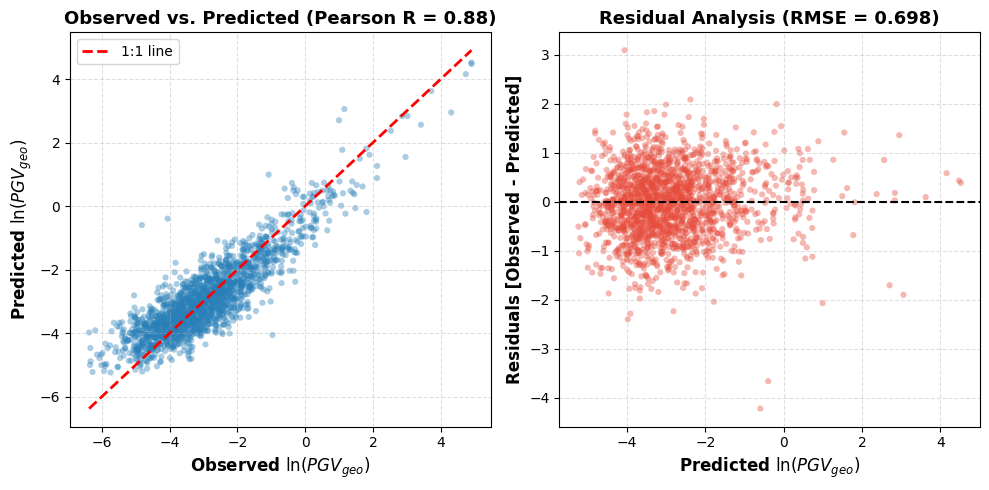

In [12]:
residuals_test = y_test - y_pred_test
test_rmse = test_metrics[1]
test_r = test_metrics[4]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Subplot 1: Observed vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.4, color='#2980b9', edgecolors='none', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1 line')
axes[0].set_title(f'Observed vs. Predicted (Pearson R = {test_r:.2f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel(r'Observed $\ln(PGV_{geo})$', fontsize=12, fontweight='bold')
axes[0].set_ylabel(r'Predicted $\ln(PGV_{geo})$', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Subplot 2: Residuals plot
axes[1].scatter(y_pred_test, residuals_test, alpha=0.4, color='#e74c3c', edgecolors='none', s=20)
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_title(f'Residual Analysis (RMSE = {test_rmse:.3f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel(r'Predicted $\ln(PGV_{geo})$', fontsize=12, fontweight='bold')
axes[1].set_ylabel(r'Residuals [Observed - Predicted]', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 2.2 Gradient Boosting ML algorithm (with Hyperparameter Tuning using GridSearchCV)

To optimize model predictions and improve generalizability, hyperparameter tuning can be performed using **GridSearchCV** with **5-Fold Cross-Validation**. 

We search over key parameters:
- `n_estimators`: Number of boosting stages. Default is `100`.
- `learning_rate`: Shrinkage parameter to prevent overfitting. Default is `0.1`.
- `max_depth`: Maximum depth of individual regression trees. Default is `3`.
- `subsample`: Fraction of samples used for fitting individual base learners. Default is `1.0`.

Here, we use **5-Fold Cross-Validation** so that every recording in the dataset is used exactly once as the test set and 4 times as the training set. This approach helps control overfitting. It also ensures that the best hyperparameter combination is selected based on consistent performance across the entire dataset, rather than by chance during hyperparameter optimization (GridSearchCV).

In [13]:
# Define Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# Initialize ML Model
gb_base = GradientBoostingRegressor(random_state=42)

# GridSearchCV with 5-Fold Cross Validation
grid_search = GridSearchCV(estimator=gb_base, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print("Starting Hyperparameter Search: ")
grid_search.fit(X_train, y_train)

best_gb_model = grid_search.best_estimator_

print("\nBest hyperparameters found: ")
for param, val in grid_search.best_params_.items():
    print(f"{param:15s}: {val}")

# Prediction using tuned model
y_pred_train_tuned = best_gb_model.predict(X_train)
y_pred_test_tuned = best_gb_model.predict(X_test)

# Performance
train_metrics_tuned = evaluate_gmm_metrics(y_train, y_pred_train_tuned)
test_metrics_tuned = evaluate_gmm_metrics(y_test, y_pred_test_tuned)

comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'Pearson R'],
    'Default Test': test_metrics,
    'Tuned Test': test_metrics_tuned
})

print("\nPerformance Comparison (Test Set): ")
display(comparison_df.round(4))

Starting Hyperparameter Search: 
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best hyperparameters found: 
learning_rate  : 0.1
max_depth      : 5
n_estimators   : 300
subsample      : 0.8

Performance Comparison (Test Set): 


,Metric,Default Test,Tuned Test
0,MSE,0.4872,0.3951
1,RMSE,0.6980,0.6286
2,MAE,0.5472,0.4907
3,MAPE (%),38.4351,34.0005
4,Pearson R,0.8830,0.9060


## 3. Visualizing Performance Improvement

Here, you might see a simple comparison script for total residual distributions of the **Default** and **Tuned** Gradient Boosting models.

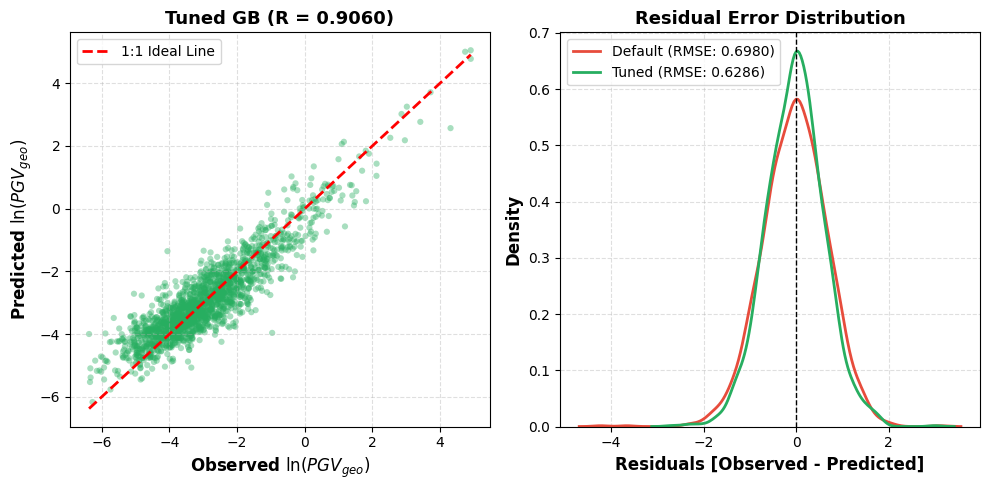

In [14]:
res_default = y_test - y_pred_test
res_tuned = y_test - y_pred_test_tuned

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Tuned Observed vs Predicted
axes[0].scatter(y_test, y_pred_test_tuned, alpha=0.4, color='#27ae60', edgecolors='none', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1 Ideal Line')
axes[0].set_title(f'Tuned GB (R = {test_metrics_tuned[4]:.4f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel(r'Observed $\ln(PGV_{geo})$', fontsize=12, fontweight='bold')
axes[0].set_ylabel(r'Predicted $\ln(PGV_{geo})$', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Residual Distribution
sns.kdeplot(res_default, ax=axes[1], color='#e74c3c', label=f'Default (RMSE: {test_metrics[1]:.4f})', lw=2)
sns.kdeplot(res_tuned, ax=axes[1], color='#27ae60', label=f'Tuned (RMSE: {test_metrics_tuned[1]:.4f})', lw=2)
axes[1].axvline(0, color='black', linestyle='--', lw=1)
axes[1].set_title('Residual Error Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residuals [Observed - Predicted]', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()